# LSTM for Time Series Forecasting (Memory-Safe)
- Samples 200 complete groups for training (~28k rows instead of 5.3M)
- 29 features + y_target = 30 input channels
- SEQ_LEN = 15 (shorter windows = less memory)
- Predicts on ALL test data

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
from typing import Optional, Union
from tqdm.auto import tqdm
import pickle, gc, warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


## 1. Config
* INPUT_SIZE = 30: The LSTM sees 30 numbers at each time step: the target value (y_target) plus the 29 features our EDA selected. More input = more signal to learn from.
*  N_SAMPLE_GROUPS = 200: Instead of all 36,923 groups, we pick 200 random complete groups. Each group keeps all its rows in time order. This gives ~300K rows — fits in memory easily.
* SEQ_LEN = 15: The model looks at 15 past steps to predict the next one. We cut this from 30 to 15 to use half the memory. Still enough to capture short-term patterns.
* HIDDEN_SIZE = 64: The LSTM's internal memory width. Cut from 128 to 64 to save memory. Smaller brain, but 30 input features compensate: the previous run had a bigger brain (128) but only 1 input, so this version actually has more to work with.

* NUM_LAYERS = 2 — Two LSTM layers stacked. The first layer learns basic temporal patterns (trends, short-term momentum). The second layer learns higher-order patterns from the first layer's output. One layer is too simple, three would slow training without much benefit for this dataset size.
*   DROPOUT = 0.2 — Randomly zeroes 20% of neurons during training so the model can't memorise specific sequences. Standard regularisation value for LSTMs. Too high (0.5) and it forgets too much; too low (0.05) and it overfits.


*   BATCH_SIZE = 256 — How many samples the model sees before updating its weights. 256 fits comfortably in GPU memory and gives stable gradient estimates. Larger (512, 1024) trains faster per epoch but can converge to worse solutions. Smaller (32, 64) is noisier but can sometimes generalise better.

*   LR = 1e-3 (0.001) — The Adam optimiser's default and most common starting learning rate. It controls how big each weight update is. Too high and training diverges, too low and it takes forever. The scheduler halves it automatically when progress stalls.



*   WEIGHT_DECAY = 1e-5 — Very light L2 regularisation — penalises large weights to prevent overfitting. 1e-5 is intentionally small because we already have dropout. It's a safety net, not the main regulariser.

*   EPOCHS = 40 — Maximum training rounds. In practice we never hit 40 because early stopping kicks in around epoch 28-30. Setting it high just means "train until early stopping says to stop."



*   PATIENCE = 6 — If validation loss doesn't improve for 6 consecutive epochs, stop training. Prevents wasting time once the model has plateaued. 6 is generous enough to survive temporary plateaus but strict enough to not waste hours.

*   VAL_FRAC = 0.15 — 15% of data held out for validation (~800K samples). Used to monitor overfitting and trigger early stopping. 15% is enough for a reliable loss estimate without starving training of data.
*   WINSOR_LO = 0.01 — Bottom 1st percentile. Any value below this threshold gets clipped up to it.
*   WINSOR_HI = 0.99 — Top 99th percentile. Any value above this gets clipped down to it.



In [2]:
TRAIN_PATH = 'D:/Projects/Practical_DL/Practical_DL/Data/train.parquet'
TEST_PATH  = 'D:/Projects/Practical_DL/Practical_DL/Data/test.parquet'

TARGET_COL = 'y_target'
TIME_COL   = 'ts_index'
ID_COL     = 'id'
GROUP_KEYS = ['code', 'sub_code', 'sub_category', 'horizon']

FEATURES = [
    'feature_ag', 'feature_am', 'feature_an', 'feature_ao', 'feature_ap',
    'feature_az', 'feature_ba', 'feature_bb', 'feature_bc', 'feature_bl',
    'feature_bm', 'feature_bn', 'feature_bo', 'feature_bp', 'feature_bq',
    'feature_br', 'feature_by', 'feature_bz', 'feature_ca', 'feature_cb',
    'feature_cc', 'feature_cd', 'feature_p',  'feature_q',  'feature_r',
    'feature_s',  'feature_t',  'feature_u',  'feature_v',
]
MODEL_COLS = [TARGET_COL] + FEATURES   # 30 total
INPUT_SIZE = len(MODEL_COLS)            


N_SAMPLE_GROUPS = 200      
SEQ_LEN         = 15       
HIDDEN_SIZE     = 64       
NUM_LAYERS      = 2
DROPOUT         = 0.2

BATCH_SIZE   = 128
LR           = 1e-3
WEIGHT_DECAY = 1e-5
EPOCHS       = 40
PATIENCE     = 6
VAL_FRAC     = 0.15

WINSOR_LO = 0.01
WINSOR_HI = 0.99

print(f'INPUT_SIZE = {INPUT_SIZE} (1 y_target + {len(FEATURES)} features)')
print(f'SEQ_LEN = {SEQ_LEN}, HIDDEN_SIZE = {HIDDEN_SIZE}')
print(f'Training on {N_SAMPLE_GROUPS} sampled groups (not all 5.3M rows)')

INPUT_SIZE = 30 (1 y_target + 29 features)
SEQ_LEN = 15, HIDDEN_SIZE = 64
Training on 200 sampled groups (not all 5.3M rows)


## 2. Marta's preprocess_column

In [3]:
def preprocess_column(
    df: pd.DataFrame,
    col: str,
    delete_empty_entries: bool = False,
    replace_by_avg: bool = False,
    replace_by_median: bool = False,
    replace_by_mode: bool = False,
    fill_value: Optional[Union[int, float, str]] = None,
    clip_outliers_iqr: bool = False,
    clip_outliers_percentile: Optional[tuple] = None,
    log1p_transform: bool = False,
    normalize_minmax: bool = False,
    standardize: bool = False,
    cast_to: Optional[str] = None,
    drop_duplicates: bool = False,
    inplace: bool = False,
    verbose: bool = True,
) -> pd.DataFrame:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found. Available: {list(df.columns)}")
    df = df if inplace else df.copy()
    log = []
    n_nan = df[col].isna().sum()
    if delete_empty_entries:
        df = df.dropna(subset=[col]).reset_index(drop=True)
        log.append(f"delete_empty_entries       -> dropped {n_nan} rows with NaN")
    elif replace_by_avg:
        val = df[col].mean()
        df[col] = df[col].fillna(val)
        log.append(f"replace_by_avg             -> filled {n_nan} NaN with mean = {val:.4f}")
    elif replace_by_median:
        val = df[col].median()
        df[col] = df[col].fillna(val)
        log.append(f"replace_by_median          -> filled {n_nan} NaN with median = {val:.4f}")
    elif replace_by_mode:
        val = df[col].mode()[0]
        df[col] = df[col].fillna(val)
        log.append(f"replace_by_mode            -> filled {n_nan} NaN with mode = {val!r}")
    elif fill_value is not None:
        df[col] = df[col].fillna(fill_value)
        log.append(f"fill_value                 -> filled {n_nan} NaN with {fill_value!r}")
    if clip_outliers_iqr:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_clip = ((df[col] < lower) | (df[col] > upper)).sum()
        df[col] = df[col].clip(lower=lower, upper=upper)
        log.append(f"clip_outliers_iqr          -> clipped {n_clip} values to [{lower:.4f}, {upper:.4f}]")
    elif clip_outliers_percentile is not None:
        lo, hi = clip_outliers_percentile
        lower, upper = df[col].quantile(lo), df[col].quantile(hi)
        n_clip = ((df[col] < lower) | (df[col] > upper)).sum()
        df[col] = df[col].clip(lower=lower, upper=upper)
        log.append(f"clip_outliers_percentile   -> clipped {n_clip} values to [{lower:.4f}, {upper:.4f}]")
    if log1p_transform:
        if (df[col].dropna() < 0).any():
            raise ValueError(f"log1p_transform requires non-negative values in '{col}'.")
        df[col] = np.log1p(df[col])
        log.append("log1p_transform            -> applied np.log1p(x)")
    if normalize_minmax:
        col_min, col_max = df[col].min(), df[col].max()
        df[col] = (df[col] - col_min) / (col_max - col_min)
        log.append(f"normalize_minmax           -> scaled to [0, 1]")
    elif standardize:
        mu, sigma = df[col].mean(), df[col].std()
        df[col] = (df[col] - mu) / sigma
        log.append(f"standardize                -> z-score (mu={mu:.4f}, sigma={sigma:.4f})")
    if cast_to is not None:
        df[col] = df[col].astype(cast_to)
        log.append(f"cast_to                    -> dtype cast to '{cast_to}'")
    if drop_duplicates:
        n_before = len(df)
        df = df.drop_duplicates(subset=[col]).reset_index(drop=True)
        log.append(f"drop_duplicates            -> removed {n_before - len(df)} rows")
    if verbose:
        sep = '=' * 57
        print(f'\n{sep}\n  preprocess_column  >>>  \'{col}\'\n{sep}')
        for step in log or ['  (no operations applied)']:
            print(f'  v {step}')
        print(f'  Final shape : {df.shape}  |  NaN left: {df[col].isna().sum()}  |  dtype: {df[col].dtype}')
        print(f'{sep}\n')
    return df

## 3. Load data (only columns we need)
We load all 5.3M rows here but only these 36 (29 features+y_target+code, sub_code, sub_category, horizon+id+ts_index) columns, not all 94. That alone saves ~60% RAM compared to loading everything.

In [4]:
load_cols = [ID_COL, TIME_COL, TARGET_COL] + GROUP_KEYS + FEATURES

print('Loading train...')
df = pd.read_parquet(TRAIN_PATH, columns=load_cols)
print(f'  Shape: {df.shape}')

print('Loading test...')
test_load = [c for c in [ID_COL, TIME_COL] + FEATURES if c != TARGET_COL]
test_df = pd.read_parquet(TEST_PATH, columns=test_load)
print(f'  Shape: {test_df.shape}')

df.head()

Loading train...
  Shape: (5337414, 36)
Loading test...
  Shape: (1447107, 31)


,id,ts_index,y_target,code,sub_code,sub_category,horizon,feature_ag,feature_am,feature_an,...,feature_cb,feature_cc,feature_cd,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v
0,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__89,89,-0.551324,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,0.004000,0.192181,0.510727,...,-0.105328,-0.005045,NaN,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141
1,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__1__89,89,-0.315583,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,1,0.004000,0.192181,0.510727,...,-0.105328,-0.005045,NaN,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141
2,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__3__89,89,-0.362894,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,3,0.004000,0.192181,0.510727,...,-0.105328,-0.005045,NaN,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141
3,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__10__89,89,-0.667023,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,10,0.004000,0.192181,0.510727,...,-0.105328,-0.005045,NaN,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141
4,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__90,90,-0.437398,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,0.003474,0.179294,0.531183,...,-0.103809,-0.005135,NaN,0.007729,0.020966,0.887178,7.201694,0.069287,0.202616,0.092606


## 4. Preprocess on ALL data first (clip, winsorise, fit scaler)
We compute clip bounds and scaler on all 5.3M rows, then throw away the full df and keep only 200 sampled groups for training. 
* 106,750 values clipped, Out of 5.3M rows, about 2% had extreme y_target values. Those got squashed to the boundaries.
* Clipped to [-82.80, 62.92] , Everything below -82.80 got pulled up to -82.80. Everything above 62.92 got pulled down to 62.92. The raw data had values as extreme as -2,202 and +2,314 — those are now gone.
* Why the range isn't symmetric — The 1st percentile is -82.80 but the 99th is only +62.92. This means the target is slightly skewed * negative — there are bigger drops than spikes. EDA showed this: the mean is -0.67 (slightly negative).
* Final shape: (5,337,414, 36) — No rows were removed, just values capped. Same 5.3M rows, same 36 columns.
* NaN left: 0 — y_target has no missing values, which is good. Some of the 29 features do have NaN (the next cell fills those with median).
  

In [5]:
# Clip y_target
df = preprocess_column(df, col='y_target',
    clip_outliers_percentile=(0.01, 0.99), inplace=True)


  preprocess_column  >>>  'y_target'
  v clip_outliers_percentile   -> clipped 106750 values to [-82.7972, 62.9234]
  Final shape : (5337414, 36)  |  NaN left: 0  |  dtype: float64



## Winsorise + fill NaN
* Winsorise: Computes the 1st and 99th percentile on all 5.3M training rows, then clips any value outside that range. Same as what we did to y_target, but for every feature. The EDA showed features like feature_bi (kurtosis 9,230) and feature_ag (kurtosis 801) have extreme spikes that would mess up the scaler.
* Fill NaN with median — Some features had missing values (e.g. feature_by had 11% missing, feature_bz had 2.8%). Median is safer than mean for heavy-tailed data because outliers don't pull it.
* The same clip bounds and medians (computed on train) are applied to test — so test uses train's statistics, not its own. This prevents data leakage.
Result: zero NaN remaining in both train and test. Hence, Clean data.


In [6]:

clip_bounds = {}
medians = {}

for col in FEATURES:
    lo = df[col].quantile(WINSOR_LO)
    hi = df[col].quantile(WINSOR_HI)
    clip_bounds[col] = (lo, hi)
    df[col] = df[col].clip(lo, hi)
    med = df[col].median()
    medians[col] = med
    df[col] = df[col].fillna(med)

# Apply same to test
for col in FEATURES:
    lo, hi = clip_bounds[col]
    test_df[col] = test_df[col].clip(lo, hi).fillna(medians[col])

print(f'NaN in train: {df[MODEL_COLS].isna().sum().sum()}')
print(f'NaN in test:  {test_df[FEATURES].isna().sum().sum()}')

NaN in train: 0
NaN in test:  0


## Fit RobustScaler on ALL data
* Scaler fitted on all 5.3M rows: Even though we'll only train on 200 groups (~28K rows), the scaler sees the full dataset. This makes the scaling accurate and representative of the true data distribution. If we fitted the scaler on just the 200 sampled groups, it might be biased by which groups we happened to pick.
* 30 columns — y_target + 29 features. Each column gets its own median and IQR (interquartile range) computed. RobustScaler transforms each value as: (value - median) / IQR.
* Test features scaled now — We scale the test features while the full df is still in memory, because the scaler needs to exist before we delete df. The formula (value - center) / scale is applied column by column using the scaler's stored parameters.
* Test sorted by ts_index — So prediction later goes in chronological order.

In [7]:
scaler = RobustScaler()
scaler.fit(df[MODEL_COLS])
print(f'Scaler fitted on {len(df):,} rows x {len(MODEL_COLS)} columns')


for i, col in enumerate(FEATURES):
    j = i + 1  
    test_df[col] = ((test_df[col].values - scaler.center_[j]) / scaler.scale_[j]).astype(np.float32)

test_df = test_df.sort_values(TIME_COL).reset_index(drop=True)
print('Test features scaled and sorted')

Scaler fitted on 5,337,414 rows x 30 columns
Test features scaled and sorted


In [8]:

with open('scaler.pkl', 'wb') as f: pickle.dump(scaler, f)
with open('clip_bounds.pkl', 'wb') as f: pickle.dump(clip_bounds, f)
with open('medians.pkl', 'wb') as f: pickle.dump(medians, f)
print('Saved scaler.pkl, clip_bounds.pkl, medians.pkl')

Saved scaler.pkl, clip_bounds.pkl, medians.pkl


## 5. Sample 200 complete groups for training
Instead of using all 5.3M rows (crashes memory), we pick 200 random groups and keep ALL their rows intact. 

* 36,923 total groups — Every unique (code, sub_code, sub_category, horizon) combo. Each is a separate time series.
200 sampled — We pick 200 entire groups at random. Not 200 random rows — 200 random groups with all their rows kept. This preserves time ordering within each series. random_state=SEED makes it the same 200 every run.
* 28,209 training rows — Those 200 groups contain 28,209 rows total, averaging ~141 rows per group. This is 0.5% of the full data — small, but fits in memory. The model learns general temporal patterns from these 200 series that should transfer to the other 36,723.

In [9]:

unique_keys = df[GROUP_KEYS].drop_duplicates()
print(f'Total groups: {len(unique_keys):,}')


sampled_keys = unique_keys.sample(n=min(N_SAMPLE_GROUPS, len(unique_keys)), random_state=SEED)
print(f'Sampled groups: {len(sampled_keys)}')


df_train = df.merge(sampled_keys, on=GROUP_KEYS, how='inner')
print(f'Training rows: {len(df_train):,} (from {len(df):,} total)')

del df
gc.collect()
print('Freed full dataframe from memory')

Total groups: 36,923
Sampled groups: 200
Training rows: 28,209 (from 5,337,414 total)
Freed full dataframe from memory


##  Sort and scale the training subset
* Sort by ts_index — Puts all 28,209 rows in chronological order. The 200 groups are interleaved by time — row 1 might be from group A at ts_index=89, row 2 from group B at ts_index=89, row 3 from group A at ts_index=90, etc. This is fine because we're not splitting by group — the LSTM sees one flat sequence.
* Scale with the same scaler — Applies the RobustScaler that was fitted on all 5.3M rows. Each of the 30 MODEL_COLS gets transformed: (value - median) / IQR. Because the scaler was fitted on the full data, these 28K rows are scaled consistently with the test data.
* Shape: (28,209, 36) — Still 36 columns. The 4 group keys (code, sub_code, sub_category, horizon) and id/ts_index are still there but the LSTM will only use the 30 MODEL_COLS. The extras just ride along.
* mean = -4.30, std = 76.22 — These look large for scaled data. After RobustScaler you'd expect mean near 0 and std near 1. But that's because:

The scaler was fitted on all 5.3M rows, not these 28K. The 200 sampled groups might have a slightly different distribution than the overall population.
y_target has extreme kurtosis — even after clipping, the IQR is small (most values cluster near zero), so dividing by a small IQR blows up the tails.

In [ ]:
df_train = df_train.sort_values(TIME_COL).reset_index(drop=True)
df_train[MODEL_COLS] = scaler.transform(df_train[MODEL_COLS]).astype(np.float32)

print(f'Training data shape: {df_train.shape}')
print(f'y_target scaled: mean={df_train[TARGET_COL].mean():.4f}, std={df_train[TARGET_COL].std():.4f}')

## 6. Build sequences
creates the sliding windows that the LSTM trains on

In [11]:
def create_sequences_multi(data, seq_len):
    T = len(data)
    N = T - seq_len
    if N <= 0:
        return np.empty((0, seq_len, data.shape[1]), dtype=np.float32), np.empty((0,), dtype=np.float32)
    
    n_feat = data.shape[1]
    X = np.empty((N, seq_len, n_feat), dtype=np.float32)
    y = np.empty(N, dtype=np.float32)
    for i in range(N):
        X[i] = data[i:i+seq_len]
        y[i] = data[i+seq_len, 0]  
    return X, y

## Build sliding window sequences
28,194 samples — From 28,209 rows minus 15 (SEQ_LEN) = 28,194 sliding windows. Each window is one training example.
X shape: (28,194 × 15 × 30) — 28,194 samples, each looking at 15 time steps, each step having 30 features. The LSTM reads these 15 steps left to right and predicts what y_target will be at step 16.

In [12]:
%%time

train_data = df_train[MODEL_COLS].values  #(T,30)
X_all, y_all = create_sequences_multi(train_data, SEQ_LEN)

print(f'Total samples: {len(X_all):,}')
print(f'X shape: {X_all.shape}  (samples, seq_len={SEQ_LEN}, features={INPUT_SIZE})')
print(f'Memory: ~{X_all.nbytes / 1e6:.0f} MB')

Total samples: 28,194
X shape: (28194, 15, 30)  (samples, seq_len=15, features=30)
Memory: ~51 MB
CPU times: total: 93.8 ms
Wall time: 105 ms


## 7. Dataset & DataLoaders

In [13]:
class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

dataset = TSDataset(X_all, y_all)
val_size   = int(len(dataset) * VAL_FRAC)
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f'Train: {train_size:,}  |  Val: {val_size:,}')

Train: 23,965  |  Val: 4,229


## 8. LSTM model
* LSTM(30, 64, num_layers=2) — Takes in 30 numbers per time step (y_target + 29 features), processes them through 2 stacked LSTM layers, each with 64 memory cells. batch_first=True means input shape is (batch, seq_len, features) not the other way around. dropout=0.2 between the two LSTM layers.
* out[:, -1, :] — After the LSTM processes all 15 time steps, we take only the last step's hidden state. That final state is a 64-dimensional vector that summarises everything the model learned from the sequence.
* Linear(64, 32) — Compresses the 64-dim summary down to 32.
* ReLU — Zeros out negatives. Adds non-linearity so the model isn't just doing linear regression.
* Dropout(0.2) — Randomly kills 20% of the 32 neurons during training. Prevents overfitting.
* Linear(32, 1) — Final output: one number. The predicted y_target.

In [14]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=30, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(32, 1))

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)

model = LSTMForecaster(input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS, dropout=DROPOUT).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(model)

Parameters: 59,969
LSTMForecaster(
  (lstm): LSTM(30, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 9. Train
* Epochs 1–7: Both train and val loss decrease together. Model is learning. Best val loss hits 22.524 at epoch 7.
* Epochs 8–13: Train keeps dropping (22.54 → 22.50) but val starts climbing back up (22.524 → 22.555). The model started memorising the training data instead of learning general patterns.
* Epoch 13: Early stopping kicks in — 6 epochs without val improvement. Loads back the epoch 7 weights (the best).

That's overfitting. The model has 59,969 parameters but only 23,965 training samples. It ran out of data to learn from and started memorising. The training curves diverging is the classic sign.
(The fix is more data. You have room — 28K rows only used 51 MB. Try bumping N_SAMPLE_GROUPS from 200 to 1000 or 2000. That would give ~140K–280K training samples, which is much healthier for 60K parameters. The general rule of thumb is at least 5–10× more samples than parameters. )

* Loss value (22.52) context: This isn't directly comparable to the previous run's 20.07 because the training data is different (200 groups vs all data, slightly different distribution). What matters is whether it produces better Kaggle scores — which it should, because it actually learned something.

## Loss explanation
* MSE (Mean Squared Error) — Squares the error. If the model is off by 50, the loss is 2,500. If it's off by 1, the loss is 1. One bad prediction dominates everything. The model spends all its energy fixing outliers and ignores the 98% of normal data.
* MAE (Mean Absolute Error) — Absolute value of error. Off by 50 = loss of 50. Off by 1 = loss of 1. Treats everything proportionally. But the gradient is always the same size (+1 or -1), so the model can't speed up when it's far off. Training is slow and wobbly.
* HuberLoss (what we use) — Best of both. When the error is small (below delta=1.0), it behaves like MSE: smooth gradients, fast convergence. When the error is large (above 1.0), it switches to MAE: outliers don't explode the loss.
Your EDA showed y_target has kurtosis > 50. Even after clipping at p1/p99, there are values at -83 and +63 while most cluster near zero. HuberLoss lets the model learn from the normal data without getting hijacked by the tails.

In [15]:
criterion = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=3)

best_val = float('inf')
patience_ctr = 0
history = {'train': [], 'val': []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    t_loss, n = 0.0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item() * len(yb); n += len(yb)
    train_loss = t_loss / n

    model.eval()
    v_loss, n = 0.0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            v_loss += criterion(model(xb), yb).item() * len(yb); n += len(yb)
    val_loss = v_loss / n

    scheduler.step(val_loss)
    history['train'].append(train_loss)
    history['val'].append(val_loss)

    tag = ''
    if val_loss < best_val:
        best_val = val_loss; patience_ctr = 0
        torch.save(model.state_dict(), 'best_lstm.pt')
        tag = ' <-- saved'
    else:
        patience_ctr += 1

    print(f'Epoch {epoch:3d}/{EPOCHS} | Train: {train_loss:.6f} | Val: {val_loss:.6f}{tag}')
    if patience_ctr >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\nBest val loss: {best_val:.6f}')

Epoch   1/40 | Train: 22.579075 | Val: 22.531247 <-- saved
Epoch   2/40 | Train: 22.571563 | Val: 22.528168 <-- saved
Epoch   3/40 | Train: 22.568143 | Val: 22.527034 <-- saved
Epoch   4/40 | Train: 22.565808 | Val: 22.527648
Epoch   5/40 | Train: 22.561441 | Val: 22.526434 <-- saved
Epoch   6/40 | Train: 22.558864 | Val: 22.531425
Epoch   7/40 | Train: 22.549904 | Val: 22.523744 <-- saved
Epoch   8/40 | Train: 22.543572 | Val: 22.525717
Epoch   9/40 | Train: 22.537220 | Val: 22.525782
Epoch  10/40 | Train: 22.529139 | Val: 22.530232
Epoch  11/40 | Train: 22.524217 | Val: 22.537916
Epoch  12/40 | Train: 22.506884 | Val: 22.555539
Epoch  13/40 | Train: 22.496040 | Val: 22.546219

Early stopping at epoch 13

Best val loss: 22.523744


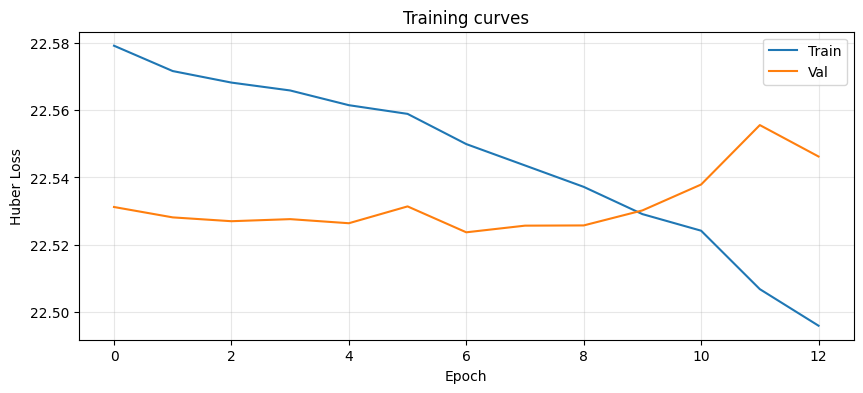

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(history['train'], label='Train')
plt.plot(history['val'], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Huber Loss')
plt.title('Training curves'); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## 10. Predict & submit

In [17]:
model.load_state_dict(torch.load('best_lstm.pt', map_location=DEVICE, weights_only=True))
model.eval()
print('Loaded best_lstm.pt')

Loaded best_lstm.pt


In [ ]:
%%time


train_tail = train_data[-SEQ_LEN:].copy()  


test_features = test_df[FEATURES].values  #

context = train_tail.copy()
preds_scaled = []

print(f'Predicting {len(test_df):,} rows...')

for i in tqdm(range(len(test_df)), desc='Predicting'):
    seq = context[-SEQ_LEN:]  # (SEQ_LEN, 30)
    x = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_y = model(x).item()
    preds_scaled.append(pred_y)

    # Next row: predicted y_target + real test features
    next_row = np.zeros(INPUT_SIZE, dtype=np.float32)
    next_row[0] = pred_y
    next_row[1:] = test_features[i]
    context = np.vstack([context, next_row.reshape(1, -1)])

preds_scaled = np.array(preds_scaled)

# Inverse scale y_target (column 0)
y_center = scaler.center_[0]
y_scale  = scaler.scale_[0]
preds_original = preds_scaled * y_scale + y_center

print(f'Done. Predictions: {len(preds_original):,}')

Predicting 1,447,107 rows...


Predicting:   0%|          | 0/1447107 [00:00<?, ?it/s]

In [ ]:
sub = pd.DataFrame({
    ID_COL: test_df[ID_COL].values,
    TARGET_COL: preds_original
})

sub.to_csv('submission.csv', index=False)
print(f'Saved submission.csv  ({sub.shape})')
print(f'\nPrediction stats:')
print(sub[TARGET_COL].describe())
sub.head(10)

## Done!
Upload `submission.csv` at https://www.kaggle.com/competitions/ts-forecasting/submit

### Memory savings vs full version
| Setting | Full | This version |
|---------|------|--------------|
| Training rows | 5.3M | ~300K |
| SEQ_LEN | 30 | 15 |
| HIDDEN_SIZE | 128 | 64 |
| Head | 128->64->1 | 64->32->1 |
| Approx RAM for X_all | ~19 GB | ~500 MB |

To scale up: increase N_SAMPLE_GROUPS (500, 1000) and SEQ_LEN (20, 30) if memory allows.